## TabTransformer Model (Tensorflow/Keras) using all available features

This notebook follows the same workflow as the other model (tensorflow/keras) notebooks of the project:
 1. data loading →
 2. initial model →
3. Optuna fine-tuning →
4. threshold selection →
5. test-set evaluation),

but the model implemented here is the **TabTransformer**, a Transformer-based architecture for tabular data, built according to the official Keras example: [Structured data learning with TabTransformer](https://keras.io/examples/structured_data/tabtransformer/) (paper: [TabTransformer: Tabular Data Modeling Using Contextual Embeddings, Huang et al., 2020](https://arxiv.org/abs/2012.06678)).

### Part 1

####  1.1 Importing the necessary libraries and constant variables


If using google colab, use the following code:


In [1]:
run_in_colab = False

In [2]:
def if_colab_run_this():
    import os
    # Clone the repo into Colab's working directory
    !git clone https://github.com/wip-0/ds207_final_project.git /content/ds207_final_project

    # Install optuna in google colab
    !pip install optuna

    # Add project root to Python path so 'src' is importable
    import sys
    sys.path.insert(0, '/content/ds207_final_project')
    # Verify src exists
    from pathlib import Path
    src_path = Path('/content/ds207_final_project/src')
    print(f"src exists: {src_path.exists()}")
    print("src contents:")
    for item in sorted(src_path.iterdir()):
        print(f"  {item.name}")

# apply the function only if you run it in google colab:
if run_in_colab:
    if_colab_run_this()

In [3]:
import os
import tempfile
import json
import math
from pathlib import Path

# custom imports
from src.utils.data_fetch import DataLoader
from src.utils.model_eval.evaluation import evaluate_predictions
from src.visualisations.viz_model import plot_confusion_matrix

# for implementing the TabTransformer neural network
# (keras + keras.layers + keras.ops, as in the Keras TabTransformer example)
import tensorflow as tf
import keras
from keras import layers
from keras import ops
import random
import re

# other essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for data preprocessing
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

# various scoring metrics
from sklearn.metrics import (classification_report, accuracy_score,
                             recall_score, precision_score,
                             f1_score, roc_auc_score, average_precision_score)

# for hyperparameter tuning
import optuna
from functools import partial

def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for path in [current, *current.parents]:
        if (path / '.paths').exists() or (path / 'pyproject.toml').exists():
            return path
    return current

# export path for the final model:
project_root = find_project_root()
export_dir = project_root / 'models' / 'tabtransformer'
export_dir.mkdir(parents=True, exist_ok=True)

SEED = 1234

/Users/vtsoumpris/PycharmProjects/ds207_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


####  1.2 Loading the data

For quickly loading data:

In [4]:
def import_data(version='final_onehot', access= 'remote'):
    """
    Import train, validation, and test datasets.

    Parameters:
    - version: str, one of 'interim', 'final_raw', 'final_label', 'final_onehot'
    - access: str, 'local' or 'remote'
    """

    version_map = {
        'interim': 'interim/split_kf_group_stratified',
        'final_raw': 'final_processed/base_kf/raw',
        'final_label': 'final_processed/base_kf/label',
        'final_onehot': 'final_processed/base_kf/onehot'
    }

    if access == 'remote':
        # Use the DataLoader which handles remote URLs properly
        loader = DataLoader()
        return loader.fetch_data(version=version)

    elif access == 'local':
        import pandas as pd
        from pathlib import Path

        # Find project root (where .paths file is located)
        current = Path.cwd()
        while not (current / '.paths').exists():
            if current.parent == current:
                raise FileNotFoundError("Could not find project root with .paths file")
            current = current.parent

        project_root = current
        data_dir = project_root / 'data' / version_map[version]

        # Check if directory exists
        if not data_dir.exists():
            raise FileNotFoundError(
                f"Data directory does not exist: {data_dir}\n"
                f"Please use access='remote' to download from GitHub, "
                f"or ensure local data is available."
            )

        # Read the CSV files
        df_Xtrain = pd.read_csv(data_dir / 'X_train_mini.csv', low_memory=False)
        df_Xval = pd.read_csv(data_dir / 'X_val.csv', low_memory=False)
        df_Xtest = pd.read_csv(data_dir / 'X_test.csv', low_memory=False)
        df_ytrain = pd.read_csv(data_dir / 'y_train_mini.csv', low_memory=False)
        df_yval = pd.read_csv(data_dir / 'y_val.csv', low_memory=False)
        df_ytest = pd.read_csv(data_dir / 'y_test.csv', low_memory=False)

        print(f"Data imported successfully from: {data_dir}")
        return df_Xtrain, df_Xval, df_Xtest, df_ytrain, df_yval, df_ytest

    else:
        raise ValueError(f"Invalid access type: {access}."
                           f"Choose 'local' or 'remote'")

**Loading the data:**

Unlike the logistic regression notebooks (which used the one-hot encoded version), the TabTransformer requires the **label-encoded** (`final_label`) version of the data: each categorical feature must be an integer code so that it can be mapped to its own trainable embedding table.

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = import_data(version='final_label',
                                                             access='remote')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/label/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/label/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/label/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/label/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/label/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/label/y_test.csv 
Data imported succesfully from paths


In [6]:
X_train.head()

,pipeline_label__max_glu_serum,pipeline_label__A1Cresult,pipeline_label__race,pipeline_label__gender,pipeline_label__age,pipeline_raw__encounter_id,pipeline_admission_type_label__admission_type_id,pipeline_discharge_label__discharge_disposition_id,pipeline_admission_src_label__admission_source_id,pipeline_medical_label__medical_specialty,...,pipeline_prescript_label__metformin-rosiglitazone,pipeline_prescript_label__metformin-pioglitazone,pipeline_standard__time_in_hospital,pipeline_standard__num_lab_procedures,pipeline_standard__num_procedures,pipeline_standard__num_medications,pipeline_standard__number_outpatient,pipeline_standard__number_emergency,pipeline_standard__number_inpatient,pipeline_standard__number_diagnoses
0,3.0,3.0,2.0,0.0,1.0,149190,1.0,0.0,0.0,11.0,...,0.0,0.0,-0.470473,0.823161,-0.782086,0.245909,-0.291189,-0.199957,-0.500694,0.820593
1,3.0,3.0,0.0,0.0,2.0,64410,1.0,0.0,0.0,11.0,...,0.0,0.0,-0.805790,-1.629771,2.148426,-0.369472,1.244021,-0.199957,0.285436,-0.729658
2,3.0,3.0,2.0,1.0,3.0,500364,1.0,0.0,0.0,11.0,...,0.0,0.0,-0.805790,0.056620,-0.195984,-0.000244,-0.291189,-0.199957,-0.500694,-0.212908
3,3.0,3.0,2.0,1.0,4.0,16680,1.0,0.0,0.0,11.0,...,0.0,0.0,-1.141107,0.414339,-0.782086,-0.984853,-0.291189,-0.199957,-0.500694,-1.246408
4,3.0,3.0,2.0,1.0,5.0,35754,1.0,0.0,1.0,11.0,...,0.0,0.0,-0.470473,-0.607716,2.734529,-0.000244,-0.291189,-0.199957,-0.500694,0.820593


In [7]:
y_train.head()

,readmitted
0,1
1,0
2,0
3,0
4,1


####  1.3 Preprocessing features

The 'final label' version of the data includes all categorical features label(integer)-encoded and all numeric features standardised. This is exactly the input format the TabTransformer needs. More specifically, the integer category codes are fed into per-feature embedding layers, while the standardised numeric features are passed to the model directly. Therefore, no additional data preprocessing will be implemented, apart from shifting the category codes so they start at 0 (a requirement of Keras `Embedding` layers) and converting the target to a numeric numpy array.

In [8]:
def target_to_numpy(y):
    if isinstance(y, pd.DataFrame):
        values = y.iloc[:, 0].copy()
    elif isinstance(y, pd.Series):
        values = y.copy()
    else:
        values = pd.Series(np.asarray(y).ravel())

    values = values.replace({'NO': 0, '>30': 1, '<30': 1})
    values = pd.to_numeric(values, errors='raise')

    return values.astype('int32').to_numpy().ravel()

#### Part 2 - Initial Model Creation

**2.1** Creating the TabTransformer model using the Keras Functional API.

**Presenting the TabTransformer architecture**

[TabTransformer](https://arxiv.org/abs/2012.06678) (Huang et al., 2020) is a deep tabular data modelling architecture for supervised and semi-supervised learning. The model is built upon self-attention based Transformers: the Transformer layers transform the embeddings of the categorical features into robust **contextual embeddings**, which capture the interactions between categorical features and achieve higher predictive accuracy.

The architecture works as follows (as presented in the [Keras example](https://keras.io/examples/structured_data/tabtransformer/)):

1. All the categorical features are encoded as embeddings, using the same `embedding_dims`. This means that each value in each categorical feature will have its own embedding vector.
2. A column embedding: one embedding vector for each categorical feature/column — can optionally be added (point-wise) to the categorical feature embedding (the paper discusses both addition and concatenation of the column embedding in the *Appendix: Experiment and Model Details* section).
3. The embedded categorical features are fed into a stack of Transformer blocks. Each Transformer block consists of a multi-head self-attention layer followed by a feed-forward layer, both wrapped with skip connections and layer normalisation.
4. The outputs of the final Transformer layer, the *contextual embeddings* of the categorical features, are flattened, concatenated with the (layer-normalised) input numerical features, and fed into a final MLP block.
5. A `sigmoid` classifier head produces the binary readmission probability.

The architecture of TabTransformer is shown below, as presented in the paper:

<img src="https://raw.githubusercontent.com/keras-team/keras-io/master/examples/structured_data/img/tabtransformer/tabtransformer.png" width="500"/>

For plotting the loss/auc/recall curves on training and validation sets:

In [9]:
def plot_model_report(history, metrics= None):
    """
    Plot training and validation curves for specified metrics from model training history.
    Examples:
    # Plot single metric
    plot_model_report(history, 'roc_auc')
    # Plot multiple metrics
    plot_model_report(history, ['loss', 'roc_auc', 'recall'])
    # Plot all available metrics (auto-detect)
    plot_model_report(history)
    """

    # Auto-detect metrics if not specified
    if metrics is None:
        # Find all metrics that have validation counterparts
        train_metrics = [k for k in history.keys() if not k.startswith('val_')]
        metrics = [m for m in train_metrics if f'val_{m}' in history.keys()]

        if not metrics:
            raise ValueError("No metrics with validation counterparts found in history")

    # Convert single metric to list
    if isinstance(metrics, str):
        metrics = [metrics]
    # Validate that all metrics exist
    for metric in metrics:
        if metric not in history:
            raise ValueError(f"Metric '{metric}' not found in history. "
                           f"Available metrics: {list(history.keys())}")
        if f'val_{metric}' not in history:
            raise ValueError(f"Validation metric 'val_{metric}' not found in history.")

    # Determine number of subplots
    n_metrics = len(metrics)
    n_cols = min(3, n_metrics)  # Max 3 columns
    n_rows = (n_metrics + n_cols - 1) // n_cols  # Ceiling division
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    # Handle single subplot case
    if n_metrics == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_metrics > 1 else [axes]

    # Plot each metric
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        # Create epoch range
        epochs = np.arange(1, len(history[metric]) + 1)
        # Plot training and validation
        ax.plot(epochs, history[metric], lw=2, color='blue', label='Train')
        ax.plot(epochs, history[f'val_{metric}'], lw=2, color='indianred', label='Validation')
        # Formatting
        metric_label = metric.replace('_', ' ').title()
        ax.set_xlabel('Epochs', size=10)
        ax.set_ylabel(metric_label, size=10)
        ax.set_title(f'{metric_label} Plot', fontweight='bold')
        ax.legend(fontsize= 10)
        ax.set_xticks(epochs, minor= True)
        ax.set_xlim(1, len(history[metric]))
        ax.grid(True, alpha=0.3)

    # Hide extra subplots if any
    for idx in range(n_metrics, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

Extracting feature dimensions, dropping ID columns, splitting the features into categorical and numerical groups, computing the embedding vocabulary (offset and size) of each categorical feature, and transforming the targets:

*Note: a few rare category codes appear only in the validation/test splits (the label encoders were fitted upstream, during preprocessing). For this reason the vocabulary bounds are computed across all three splits — this only reads the encoding's metadata (no target information is involved), so it does not leak any label information.*

In [10]:
# creating the input feature lists:
id_cols = ['pipeline_raw__encounter_id']

# drop the ID columns from the dataframes
train_df = X_train.drop(columns= id_cols)
val_df = X_val.drop(columns= id_cols)
test_df = X_test.drop(columns= id_cols)

# A list of the numerical feature names (standardised during preprocessing).
NUMERIC_FEATURE_NAMES = [
    col for col in train_df.columns if col.startswith('pipeline_standard__')
]
# A list of the categorical feature names (label/integer encoded during preprocessing).
CATEGORICAL_FEATURE_NAMES = [
    col for col in train_df.columns if col not in NUMERIC_FEATURE_NAMES
]
# A list of all the input features.
FEATURE_NAMES = NUMERIC_FEATURE_NAMES + CATEGORICAL_FEATURE_NAMES

# A dictionary of the categorical features and their vocabulary metadata:
# 'offset' shifts the codes so the smallest one maps to index 0
# (Embedding layers require non-negative indices),
# and 'vocab_size' is the number of rows of the embedding table.
CATEGORICAL_FEATURES_WITH_VOCABULARY = {}
for feature_name in CATEGORICAL_FEATURE_NAMES:
    col_min = int(min(train_df[feature_name].min(),
                      val_df[feature_name].min(),
                      test_df[feature_name].min()))
    col_max = int(max(train_df[feature_name].max(),
                      val_df[feature_name].max(),
                      test_df[feature_name].max()))
    CATEGORICAL_FEATURES_WITH_VOCABULARY[feature_name] = {
        'offset': col_min,
        'vocab_size': col_max - col_min + 1,
    }

# transform the y sets to numpy format
y_train_array = target_to_numpy(y_train)
y_val_array = target_to_numpy(y_val)
y_test_array = target_to_numpy(y_test)

# positive rate in y-train (mean)
pos_rate = y_train_array.mean()

print(f'Numerical features:   {len(NUMERIC_FEATURE_NAMES)}')
print(f'Categorical features: {len(CATEGORICAL_FEATURE_NAMES)}')
print(f'Positive rate (train): {pos_rate:.4f}')

Numerical features:   8
Categorical features: 45
Positive rate (train): 0.4713


**Converting the input dataframes into the TabTransformer input format:**

Following the Keras example, the model is built with one *named* scalar input per feature. Therefore each dataframe is converted into a dictionary of numpy arrays keyed by feature name. The categorical codes are shifted by their offset (so they start at 0) and cast to integers, while the numerical features are cast to floats.

In [11]:
def dataframe_to_inputs(df):
    """
    Convert a features dataframe into the dictionary-of-arrays format expected by
    the TabTransformer (one entry per feature, keyed by the model's input names).

    - Categorical features: codes are shifted by their offset (so the smallest code
      maps to index 0, as required by the Embedding layers) and cast to int32.
    - Numerical features: cast to float32 and passed through unchanged.
    """
    inputs = {}
    for feature_name in NUMERIC_FEATURE_NAMES:
        inputs[feature_name] = df[feature_name].to_numpy(dtype='float32')
    for feature_name in CATEGORICAL_FEATURE_NAMES:
        offset = CATEGORICAL_FEATURES_WITH_VOCABULARY[feature_name]['offset']
        codes = df[feature_name].to_numpy(dtype='int64') - offset
        inputs[feature_name] = codes.astype('int32')
    return inputs


# creating the model-ready inputs for the train, validation, and test sets
train_inputs = dataframe_to_inputs(train_df)
val_inputs = dataframe_to_inputs(val_df)
test_inputs = dataframe_to_inputs(test_df)

**Configuring the default hyperparameters** (following the Keras example):

- `EMBEDDING_DIMS`: dimension of every categorical feature embedding (shared across all features, as required by the Transformer).
- `NUM_TRANSFORMER_BLOCKS` / `NUM_HEADS`: depth of the Transformer stack and number of self-attention heads.
- `MLP_HIDDEN_UNITS_FACTORS`: hidden units of the final MLP head, expressed as factors of its input width.
- `DROPOUT_RATE`: dropout used in the attention layers and in the MLP blocks.
- `LEARNING_RATE` / `WEIGHT_DECAY`: settings of the `AdamW` optimiser used by the example.

*(The number of epochs is kept moderate compared to the logistic regression notebook, because the TabTransformer is considerably more expensive to train.)*

In [12]:
# training configuration
LEARNING_RATE = 0.0003
WEIGHT_DECAY = 0.0001
DROPOUT_RATE = 0.25
BATCH_SIZE = 512
NUM_EPOCHS = 25

# model architecture configuration
NUM_TRANSFORMER_BLOCKS = 2  # Number of transformer blocks.
NUM_HEADS = 2  # Number of attention heads.
EMBEDDING_DIMS = 16  # Embedding dimensions of the categorical features.
MLP_HIDDEN_UNITS_FACTORS = [1] # or [2, 1] # MLP hidden layer units, as factors of the number of inputs.

**Creating the model inputs:**

The inputs are defined as a dictionary, where the key is the feature name and the value is a scalar `keras.layers.Input` tensor with the corresponding data type: `int32` for the (label-encoded) categorical features and `float32` for the numerical features.

In [13]:
def create_model_inputs():
    inputs = {}
    for feature_name in FEATURE_NAMES:
        if feature_name in NUMERIC_FEATURE_NAMES:
            inputs[feature_name] = layers.Input(
                name= feature_name, shape=(), dtype='float32'
            )
        else:
            inputs[feature_name] = layers.Input(
                name= feature_name, shape=(), dtype='int32'
            )
    return inputs

**Encoding the features:**

The `encode_inputs` function returns `encoded_categorical_feature_list` and `numerical_feature_list`. We encode the categorical features as embeddings, using a fixed `embedding_dims` for all the features, regardless of their vocabulary sizes. This is required for the Transformer, which consumes a stack of same-sized embedding vectors.

Since the categories are already integer codes in this version of the data, no `StringLookup` is needed (unlike the original Keras example, which starts from raw string categories); the codes were offset-shifted during input preparation. The numerical features are used as-is (they were already standardised during preprocessing).

In [14]:
def encode_inputs(inputs, embedding_dims):
    encoded_categorical_feature_list = []
    numerical_feature_list = []

    for feature_name in inputs:
        if feature_name in CATEGORICAL_FEATURE_NAMES:
            # The categorical feature values are already integer indices
            # (label encoding, offset-shifted to start at 0), so they can be
            # fed directly to an embedding layer.
            vocab_size = CATEGORICAL_FEATURES_WITH_VOCABULARY[feature_name]['vocab_size']

            # Create an embedding layer with the specified dimensions.
            embedding = layers.Embedding(
                input_dim= vocab_size, output_dim= embedding_dims
            )

            # Convert the index values to embedding representations.
            encoded_categorical_feature = embedding(inputs[feature_name])
            encoded_categorical_feature_list.append(encoded_categorical_feature)

        else:
            # Use the numerical features as-is.
            numerical_feature = ops.expand_dims(inputs[feature_name], -1)
            numerical_feature_list.append(numerical_feature)

    return encoded_categorical_feature_list, numerical_feature_list

**Implementing an MLP block:**

A reusable helper that stacks `[normalisation → dense → dropout]` blocks. It is used both inside every Transformer block (as the feed-forward part, with `LayerNormalization` + GELU activation) and as the final MLP head (with `BatchNormalization` + SELU activation), exactly as in the Keras example.

In [15]:
def create_mlp(hidden_units, dropout_rate, activation, normalization_layer, name=None):
    mlp_layers = []
    for units in hidden_units:
        mlp_layers.append(normalization_layer())
        mlp_layers.append(layers.Dense(units, activation= activation))
        mlp_layers.append(layers.Dropout(dropout_rate))

    return keras.Sequential(mlp_layers, name=name)

**Assembling and compiling the TabTransformer classifier:**

Each Transformer block applies multi-head self-attention over the stacked categorical embeddings, followed by a feed-forward MLP. Both are wrapped with skip connections and layer normalisation. The contextual embeddings coming out of the last block are flattened, concatenated with the layer-normalised numerical features, and passed through the final MLP head, ending in a single sigmoid unit.

The model is compiled with the `AdamW` optimiser (Adam with decoupled weight decay), as in the Keras example, and reports the same metrics used across the project notebooks (ROC AUC, PR AUC, recall, precision).

In [16]:
def create_model(num_transformer_blocks= NUM_TRANSFORMER_BLOCKS,
                 num_heads= NUM_HEADS,
                 embedding_dims= EMBEDDING_DIMS,
                 mlp_hidden_units_factors= MLP_HIDDEN_UNITS_FACTORS,
                 dropout_rate= DROPOUT_RATE,
                 use_column_embedding= False,
                 lr= LEARNING_RATE,
                 weight_decay= WEIGHT_DECAY):
 """Build and compile a TabTransformer classifier using Keras.

  Args:
    num_transformer_blocks: The number of Transformer blocks.
    num_heads: The number of attention heads per block.
    embedding_dims: The embedding dimension of every categorical feature.
    mlp_hidden_units_factors: Final MLP hidden units, as factors of its input width.
    dropout_rate: Dropout rate used in the attention layers and MLP blocks.
    use_column_embedding: Whether to add a (per-column) embedding to the
      categorical feature embeddings.
    lr: The desired learning rate for AdamW.
    weight_decay: The weight decay for AdamW.

  Returns:
    model: A compiled tf.keras model (graph).
  """

 tf.random.set_seed(SEED)
 np.random.seed(SEED)
 random.seed(SEED)
 tf.keras.utils.set_random_seed(SEED)
 tf.keras.backend.clear_session()

 # Create model inputs.
 inputs = create_model_inputs()
 # Encode features.
 encoded_categorical_feature_list, numerical_feature_list = encode_inputs(
        inputs, embedding_dims
 )
 # Stack categorical feature embeddings for the Transformer:
 # shape becomes (batch_size, num_categorical_features, embedding_dims).
 encoded_categorical_features = ops.stack(encoded_categorical_feature_list, axis=1)
 # Concatenate numerical features.
 numerical_features = layers.concatenate(numerical_feature_list)

 # Add column embedding to categorical feature embeddings
 # (an embedding of the feature/column identity, added point-wise).
 if use_column_embedding:
        num_columns = encoded_categorical_features.shape[1]
        column_embedding = layers.Embedding(
            input_dim=num_columns, output_dim=embedding_dims
        )
        column_indices = ops.arange(start=0, stop=num_columns, step=1)
        encoded_categorical_features = encoded_categorical_features + column_embedding(
            column_indices
        )

 # Create multiple layers of the Transformer block.
 for block_idx in range(num_transformer_blocks):
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embedding_dims,
            dropout=dropout_rate,
            name=f'multihead_attention_{block_idx}',
        )(encoded_categorical_features, encoded_categorical_features)
        # Skip connection 1.
        x = layers.Add(name=f'skip_connection1_{block_idx}')(
            [attention_output, encoded_categorical_features]
        )
        # Layer normalization 1.
        x = layers.LayerNormalization(name=f'layer_norm1_{block_idx}', epsilon=1e-6)(x)
        # Feedforward.
        feedforward_output = create_mlp(
            hidden_units=[embedding_dims],
            dropout_rate=dropout_rate,
            activation=keras.activations.gelu,
            normalization_layer=partial(
                layers.LayerNormalization, epsilon=1e-6
            ),  # using partial to provide keyword arguments before initialization
            name=f'feedforward_{block_idx}',
        )(x)
        # Skip connection 2.
        x = layers.Add(name=f'skip_connection2_{block_idx}')([feedforward_output, x])
        # Layer normalization 2.
        encoded_categorical_features = layers.LayerNormalization(
            name=f'layer_norm2_{block_idx}', epsilon=1e-6
        )(x)

 # Flatten the "contextualized" embeddings of the categorical features.
 categorical_features = layers.Flatten()(encoded_categorical_features)
 # Apply layer normalization to the numerical features.
 numerical_features = layers.LayerNormalization(epsilon=1e-6)(numerical_features)
 # Prepare the input for the final MLP block.
 features = layers.concatenate([categorical_features, numerical_features])

 # Compute MLP hidden_units.
 mlp_hidden_units = [
        factor * features.shape[-1] for factor in mlp_hidden_units_factors
 ]
 # Create final MLP.
 features = create_mlp(
        hidden_units=mlp_hidden_units,
        dropout_rate=dropout_rate,
        activation=keras.activations.selu,
        normalization_layer=layers.BatchNormalization,
        name='MLP',
 )(features)

 # Add a sigmoid as a binary classifier.
 outputs = layers.Dense(units=1, activation='sigmoid', name='sigmoid')(features)
 model = keras.Model(inputs=inputs, outputs=outputs)

 # compiling the model using the AdamW Optimiser (as in the Keras example)
 model.compile(
        optimizer= keras.optimizers.AdamW(learning_rate= lr, weight_decay= weight_decay),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(curve='ROC', name='roc_auc'),
            keras.metrics.AUC(curve='PR', name='pr_auc'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.Precision(name='precision'),
        ],
 )
 return model

In [17]:
def build_model(lr= LEARNING_RATE,
                weight_decay= WEIGHT_DECAY,
                positive_class_weight= 1.0,
                epochs= NUM_EPOCHS,
                batch_size= BATCH_SIZE,
                train_inputs= train_inputs,
                y_train_array = y_train_array,
                val_inputs= val_inputs,
                y_val_array= y_val_array
                ):
    """
    Builds and trains a TabTransformer model
    (using the default architecture hyperparameters).
    """

    # create the TabTransformer model
    # (categorical embeddings + Transformer blocks + final MLP head)
    model = create_model(lr= lr, weight_decay= weight_decay)

    # fit the model and create a history
    history = model.fit(
        train_inputs, y_train_array,
        validation_data= (val_inputs, y_val_array),
        epochs= epochs,
        batch_size= batch_size,
        class_weight= {0: 1.0, 1: positive_class_weight},
        callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor='val_pr_auc',
                    mode='max',
                    patience= 4,
                    restore_best_weights=True
                ),
                keras.callbacks.ReduceLROnPlateau(
                    monitor='val_pr_auc',
                    mode='max',
                    factor= 0.5,
                    patience= 2,
                    min_lr= 1e-5
                )
            ]
    )

    return model, history

In [18]:
init_model, init_history = build_model(epochs = NUM_EPOCHS)

Epoch 1/25
117/117 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - loss: 0.7760 - pr_auc: 0.5251 - precision: 0.5200 - recall: 0.5007 - roc_auc: 0.5610 - val_loss: 0.7157 - val_pr_auc: 0.5849 - val_precision: 0.5158 - val_recall: 0.8215 - val_roc_auc: 0.6232 - learning_rate: 3.0000e-04
Epoch 2/25
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 0.7368 - pr_auc: 0.5435 - precision: 0.5355 - recall: 0.5025 - roc_auc: 0.5802 - val_loss: 0.6754 - val_pr_auc: 0.5887 - val_precision: 0.5594 - val_recall: 0.5902 - val_roc_auc: 0.6255 - learning_rate: 3.0000e-04
Epoch 3/25
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 0.7159 - pr_auc: 0.5544 - precision: 0.5417 - recall: 0.5070 - roc_auc: 0.5890 - val_loss: 0.6686 - val_pr_auc: 0.5944 - val_precision: 0.5952 - val_recall: 0.4635 - val_roc_auc: 0.6327 - learning_rate: 3.0000e-04
Epoch 4/25
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 0.7024 - pr_auc: 0.5596 - precision: 0.5508 - recall: 0.5076 - roc_auc: 0.5963 - val_loss: 0.6680 - val_pr_auc: 0

In [ ]:
init_model.summary()

**2.2** Plotting training and validation loss, AUC, recall curves:

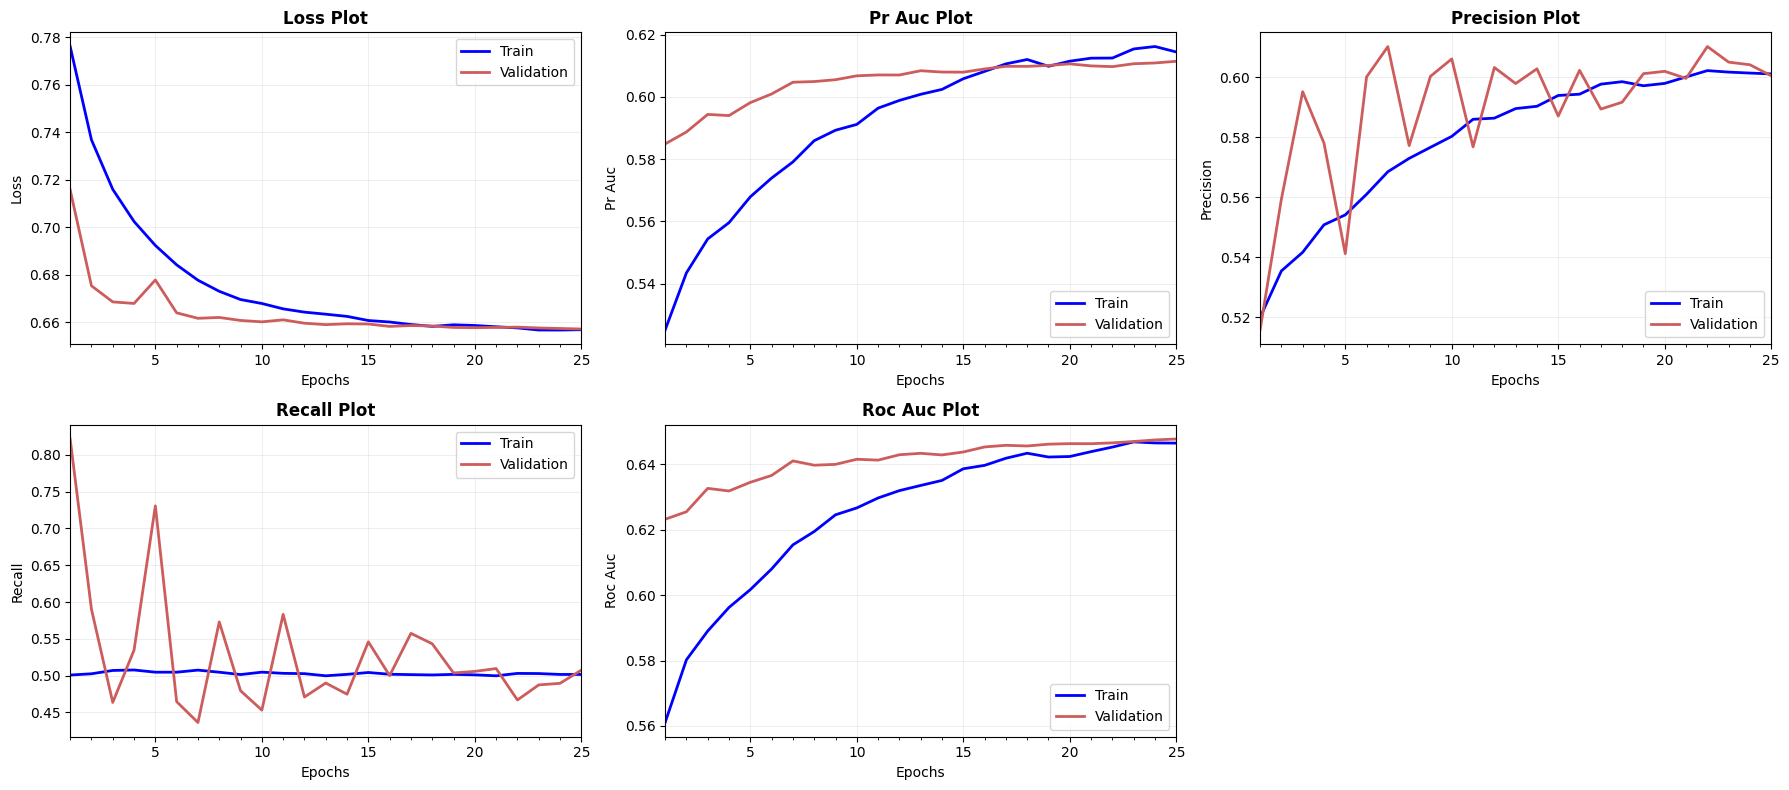

In [20]:
plot_model_report(history= init_history.history)

#### Part 3: Fine-tuning the model using Optuna

**3.1** Defining the TabTransformer architecture (hyper-parameter search space) to be optimised:

The tuned hyper-parameters cover the optimiser settings (`learning_rate`, `weight_decay`), the architecture settings (`embedding_dims`, `num_heads`, `num_transformer_blocks`, `dropout_rate`) and whether to add the optional column embedding.

In [40]:
def build_model_optuna(trial):
    # build model suitable for optuna trial
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)
    tf.keras.backend.clear_session()

    # optimiser hyper-parameters
    learning_rate = trial.suggest_categorical('learning_rate', [0.0001, 0.0003, 0.001, 0.003])
    weight_decay = trial.suggest_categorical('weight_decay', [0.00001, 0.0001, 0.001])
    # architecture hyper-parameters
    embedding_dims = trial.suggest_categorical('embedding_dims', [4, 8, 16, 32])
    num_heads = trial.suggest_categorical('num_heads', [2, 4, 8])
    num_transformer_blocks = trial.suggest_int('num_transformer_blocks', 1, 4)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.3, step= 0.05)
    use_column_embedding = trial.suggest_categorical('use_column_embedding', [True])

    model = create_model(num_transformer_blocks= num_transformer_blocks,
                         num_heads= num_heads,
                         embedding_dims= embedding_dims,
                         dropout_rate= dropout_rate,
                         use_column_embedding= use_column_embedding,
                         lr= learning_rate,
                         weight_decay= weight_decay,)

    return model

**3.2** Defining fitting function (more hyper-parameters to be optimised):

*(The number of epochs per trial is kept at 15, as in the Keras example)*

In [41]:
def fit_model_optuna(trial,
                     model,
                     batch_size,
                     positive_class_weight,
                     epochs= 15,
                     verbose= 1,
                     train_inputs= train_inputs,
                     y_train_array = y_train_array,
                     val_inputs= val_inputs,
                     y_val_array= y_val_array
                     ):

    history = model.fit(
        train_inputs, y_train_array,
        validation_data=(val_inputs, y_val_array),
        epochs= epochs,
        batch_size= batch_size,
        class_weight= {0: 1.0, 1: positive_class_weight},
        verbose= verbose,
    )

    return history

**3.3** Defining the objective function. The study optimizes validation PR AUC directly.


In [42]:
def objective_fn(trial):
    """
    Defines the objective function for an Optuna optimization trial. The function configures the
    model and its parameters, evaluates its performance, and stores the best results for analysis.
    """
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256, 512])
    positive_class_weight = trial.suggest_float('positive_class_weight', 1.0, 1.4, step= 0.05)

    # build and fit the model
    model = build_model_optuna(trial)
    history = fit_model_optuna(
        trial,
        model,
        batch_size= batch_size,
        positive_class_weight= positive_class_weight,
    )

    # the objective is to maximize the validation PR-AUC
    val_pr_auc = history.history['val_pr_auc']
    best_epoch_idx = int(np.argmax(val_pr_auc))

    # set attributes for the Optuna trial
    trial.set_user_attr('best_epoch', best_epoch_idx + 1)
    trial.set_user_attr('best_val_pr_auc', float(history.history['val_pr_auc'][best_epoch_idx]))
    trial.set_user_attr('best_val_roc_auc', float(history.history['val_roc_auc'][best_epoch_idx]))
    trial.set_user_attr('best_val_recall', float(history.history['val_recall'][best_epoch_idx]))
    trial.set_user_attr('best_val_precision', float(history.history['val_precision'][best_epoch_idx]))

    return float(history.history['val_pr_auc'][best_epoch_idx])

**3.4** Running the optimization (study):

In [24]:
def extract_best_params(study):
    """
    Extract the best parameters from a completed Optuna study.
    """
    completed_trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
    ]
    if not completed_trials:
        raise ValueError('No completed Optuna trials available. Run study.optimize first.')

    return study.best_params

In [43]:
# to load the existing study
# (saved under the model folder as a SQLite db format)
load_existing_study = False

###### ###### ######
storage_path = f"sqlite:///{export_dir / 'optuna_study_all_feats.db'}"
num_trials = 30
sec_timeout = 10800 #7200

In [44]:
# create study (or load an existing one)
study = optuna.create_study(
    study_name='tabtransformer_allfeats',
    direction='maximize',
    storage= storage_path,
    load_if_exists= True,
)

# checking if the study
# has already been completed
completed_trials = [
    trial for trial in study.trials
    if trial.state == optuna.trial.TrialState.COMPLETE
]

# Run optimization unless explicitly loading an existing study that already has results.
if (not load_existing_study) or (len(completed_trials) == 0):
    study.optimize( func= objective_fn,
                    n_trials= num_trials,
                    timeout= sec_timeout
                   )

[I 2026-07-29 16:15:33,239] A new study created in RDB with name: tabtransformer_allfeats


Epoch 1/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 36s 119ms/step - loss: 0.8723 - pr_auc: 0.5230 - precision: 0.5257 - recall: 0.5637 - roc_auc: 0.5676 - val_loss: 0.6682 - val_pr_auc: 0.5978 - val_precision: 0.6003 - val_recall: 0.4432 - val_roc_auc: 0.6246
Epoch 2/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - loss: 0.7286 - pr_auc: 0.5651 - precision: 0.5429 - recall: 0.5895 - roc_auc: 0.6034 - val_loss: 0.6711 - val_pr_auc: 0.6013 - val_precision: 0.5480 - val_recall: 0.6822 - val_roc_auc: 0.6332
Epoch 3/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - loss: 0.7250 - pr_auc: 0.5751 - precision: 0.5484 - recall: 0.5917 - roc_auc: 0.6110 - val_loss: 0.7145 - val_pr_auc: 0.6011 - val_precision: 0.4863 - val_recall: 0.9579 - val_roc_auc: 0.6340
Epoch 4/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - loss: 0.7239 - pr_auc: 0.5792 - precision: 0.5479 - recall: 0.5876 - roc_auc: 0.6130 - val_loss: 0.6655 - val_pr_auc: 0.6017 - val_precision: 0.6344 - val_recall: 0.3423 - val_roc_auc: 0.6362
Epoc

[I 2026-07-29 16:22:28,832] Trial 0 finished with value: 0.6153582334518433 and parameters: {'batch_size': 256, 'positive_class_weight': 1.15, 'learning_rate': 0.001, 'weight_decay': 0.001, 'embedding_dims': 32, 'num_heads': 4, 'num_transformer_blocks': 2, 'dropout_rate': 0.1, 'use_column_embedding': True}. Best is trial 0 with value: 0.6153582334518433.


Epoch 1/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 46s 158ms/step - loss: 0.7746 - pr_auc: 0.5505 - precision: 0.5313 - recall: 0.5969 - roc_auc: 0.5904 - val_loss: 0.7380 - val_pr_auc: 0.5822 - val_precision: 0.5060 - val_recall: 0.8628 - val_roc_auc: 0.6192
Epoch 2/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 37s 157ms/step - loss: 0.7482 - pr_auc: 0.5815 - precision: 0.5512 - recall: 0.6156 - roc_auc: 0.6194 - val_loss: 0.6943 - val_pr_auc: 0.5797 - val_precision: 0.5385 - val_recall: 0.6957 - val_roc_auc: 0.6217
Epoch 3/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 36s 156ms/step - loss: 0.7372 - pr_auc: 0.5956 - precision: 0.5600 - recall: 0.6244 - roc_auc: 0.6330 - val_loss: 0.6862 - val_pr_auc: 0.5765 - val_precision: 0.5584 - val_recall: 0.6059 - val_roc_auc: 0.6223
Epoch 4/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 36s 156ms/step - loss: 0.7288 - pr_auc: 0.6066 - precision: 0.5662 - recall: 0.6307 - roc_auc: 0.6436 - val_loss: 0.6848 - val_pr_auc: 0.5754 - val_precision: 0.5665 - val_recall: 0.5631 - val_roc_auc: 0.6220
Epoc

[I 2026-07-29 16:31:46,115] Trial 1 finished with value: 0.5821954607963562 and parameters: {'batch_size': 256, 'positive_class_weight': 1.2, 'learning_rate': 0.0001, 'weight_decay': 0.001, 'embedding_dims': 32, 'num_heads': 4, 'num_transformer_blocks': 3, 'dropout_rate': 0.0, 'use_column_embedding': True}. Best is trial 0 with value: 0.6153582334518433.


...

[I 2026-07-29 17:37:25,479] Trial 27 finished with value: 0.6354443430900574 and parameters: {'batch_size': 512, 'positive_class_weight': 1.05, 'learning_rate': 0.003, 'weight_decay': 0.0001, 'embedding_dims': 8, 'num_heads': 4, 'num_transformer_blocks': 1, 'dropout_rate': 0.05, 'use_column_embedding': True}. Best is trial 24 with value: 0.6428654193878174.


Epoch 1/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 0.7126 - pr_auc: 0.5379 - precision: 0.5382 - recall: 0.5061 - roc_auc: 0.5811 - val_loss: 0.7298 - val_pr_auc: 0.5926 - val_precision: 0.4933 - val_recall: 0.9093 - val_roc_auc: 0.6253
Epoch 2/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 0.6865 - pr_auc: 0.5727 - precision: 0.5598 - recall: 0.5042 - roc_auc: 0.6065 - val_loss: 0.6783 - val_pr_auc: 0.5975 - val_precision: 0.5404 - val_recall: 0.7095 - val_roc_auc: 0.6319
Epoch 3/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 0.6836 - pr_auc: 0.5742 - precision: 0.5628 - recall: 0.5054 - roc_auc: 0.6104 - val_loss: 0.6661 - val_pr_auc: 0.5987 - val_precision: 0.5718 - val_recall: 0.5855 - val_roc_auc: 0.6352
Epoch 4/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 0.6805 - pr_auc: 0.5801 - precision: 0.5639 - recall: 0.5070 - roc_auc: 0.6139 - val_loss: 0.6647 - val_pr_auc: 0.5992 - val_precision: 0.5939 - val_recall: 0.4795 - val_roc_auc: 0.6346
Epoch 5/15


[I 2026-07-29 17:39:21,770] Trial 28 finished with value: 0.6004590392112732 and parameters: {'batch_size': 512, 'positive_class_weight': 1.0, 'learning_rate': 0.0001, 'weight_decay': 0.001, 'embedding_dims': 16, 'num_heads': 4, 'num_transformer_blocks': 1, 'dropout_rate': 0.05, 'use_column_embedding': True}. Best is trial 24 with value: 0.6428654193878174.


Epoch 1/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - loss: 0.8219 - pr_auc: 0.5298 - precision: 0.5246 - recall: 0.5244 - roc_auc: 0.5680 - val_loss: 0.7203 - val_pr_auc: 0.5702 - val_precision: 0.5218 - val_recall: 0.7331 - val_roc_auc: 0.6083
Epoch 2/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - loss: 0.7452 - pr_auc: 0.5527 - precision: 0.5396 - recall: 0.5328 - roc_auc: 0.5905 - val_loss: 0.6753 - val_pr_auc: 0.5857 - val_precision: 0.5663 - val_recall: 0.5372 - val_roc_auc: 0.6219
Epoch 3/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - loss: 0.7137 - pr_auc: 0.5693 - precision: 0.5518 - recall: 0.5399 - roc_auc: 0.6048 - val_loss: 0.7121 - val_pr_auc: 0.5755 - val_precision: 0.6416 - val_recall: 0.1998 - val_roc_auc: 0.6171
Epoch 4/15
233/233 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - loss: 0.6956 - pr_auc: 0.5832 - precision: 0.5629 - recall: 0.5420 - roc_auc: 0.6194 - val_loss: 0.6874 - val_pr_auc: 0.5873 - val_precision: 0.5311 - val_recall: 0.7519 - val_roc_auc: 0.6273
Epoch 5/

[I 2026-07-29 17:43:22,837] Trial 29 finished with value: 0.6074748039245605 and parameters: {'batch_size': 256, 'positive_class_weight': 1.05, 'learning_rate': 0.0003, 'weight_decay': 1e-05, 'embedding_dims': 32, 'num_heads': 4, 'num_transformer_blocks': 1, 'dropout_rate': 0.1, 'use_column_embedding': True}. Best is trial 24 with value: 0.6428654193878174.


In [45]:
# extracting best parameters from the study
best_params = extract_best_params(study)
best_params

{'batch_size': 512,
 'positive_class_weight': 1.05,
 'learning_rate': 0.003,
 'weight_decay': 0.0001,
 'embedding_dims': 4,
 'num_heads': 4,
 'num_transformer_blocks': 1,
 'dropout_rate': 0.1,
 'use_column_embedding': True}

**3.5** Creating the final fine-tuned model:

In [46]:
def build_model_fine_tuned(best_parameters= best_params,
                           fit_model= True,
                           epochs= 25,
                           verbose= 1,
                           train_inputs= train_inputs,
                           y_train_array = y_train_array,
                           val_inputs= val_inputs,
                           y_val_array= y_val_array):
    # setting the seed for reproducibility
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)
    tf.keras.backend.clear_session()

    model = create_model(
        num_transformer_blocks= best_parameters['num_transformer_blocks'],
        num_heads= best_parameters['num_heads'],
        embedding_dims= best_parameters['embedding_dims'],
        dropout_rate= best_parameters['dropout_rate'],
        use_column_embedding= best_parameters['use_column_embedding'],
        lr= best_parameters['learning_rate'],
        weight_decay= best_parameters['weight_decay'],
    )

    history = None
    if fit_model:
        history = model.fit(
            train_inputs, y_train_array,
            validation_data= (val_inputs, y_val_array),
            epochs= epochs,
            batch_size= best_parameters['batch_size'],
            class_weight= {0: 1.0, 1: best_parameters['positive_class_weight']},
            verbose=verbose,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor='val_pr_auc',
                    mode='max',
                    patience=4,
                    restore_best_weights=True
                ),
                keras.callbacks.ReduceLROnPlateau(
                    monitor='val_pr_auc',
                    mode='max',
                    factor=0.5,
                    patience=2,
                    min_lr=1e-5
                )
            ]
        )
    return model, history

**Getting the structure of the model without fitting it first**:

In [47]:
model_finetuned, _ = build_model_fine_tuned(
    best_parameters=best_params,
    fit_model= False,
    epochs= 15,
    verbose= 1
)
model_finetuned.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pipeline_label__ma… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_label__A1… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_label__ra… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_label__ge… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_label__age │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_l… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_icd9_labe… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_icd9_labe… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_icd9_labe… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_prescript… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_prescript… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_prescript… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_prescript… │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_prescript… │ (None)            │          0 │ -               

 Total params: 37,617 (146.94 KB)

 Trainable params: 37,241 (145.47 KB)

 Non-trainable params: 376 (1.47 KB)

**Fitting the fine-tuned model**:

In [48]:
model_finetuned, history_fine_tuned = build_model_fine_tuned(
    best_parameters= best_params,
    fit_model= True,
    epochs= 15,
    verbose= 1
)

Epoch 1/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.7178 - pr_auc: 0.5563 - precision: 0.5499 - recall: 0.5275 - roc_auc: 0.5956 - val_loss: 0.6661 - val_pr_auc: 0.5967 - val_precision: 0.6052 - val_recall: 0.4494 - val_roc_auc: 0.6258 - learning_rate: 0.0030
Epoch 2/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.6835 - pr_auc: 0.5934 - precision: 0.5767 - recall: 0.5249 - roc_auc: 0.6263 - val_loss: 0.6649 - val_pr_auc: 0.6014 - val_precision: 0.6219 - val_recall: 0.3998 - val_roc_auc: 0.6289 - learning_rate: 0.0030
Epoch 3/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.6795 - pr_auc: 0.6018 - precision: 0.5829 - recall: 0.5240 - roc_auc: 0.6338 - val_loss: 0.6633 - val_pr_auc: 0.6033 - val_precision: 0.6139 - val_recall: 0.4201 - val_roc_auc: 0.6328 - learning_rate: 0.0030
Epoch 4/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.6778 - pr_auc: 0.6058 - precision: 0.5864 - recall: 0.5262 - roc_auc: 0.6377 - val_loss: 0.6624 - val_pr_auc: 0.6052 - val_

**Plotting AUC, Recall and Loss of the fine-tuned model (train & validation set)**:

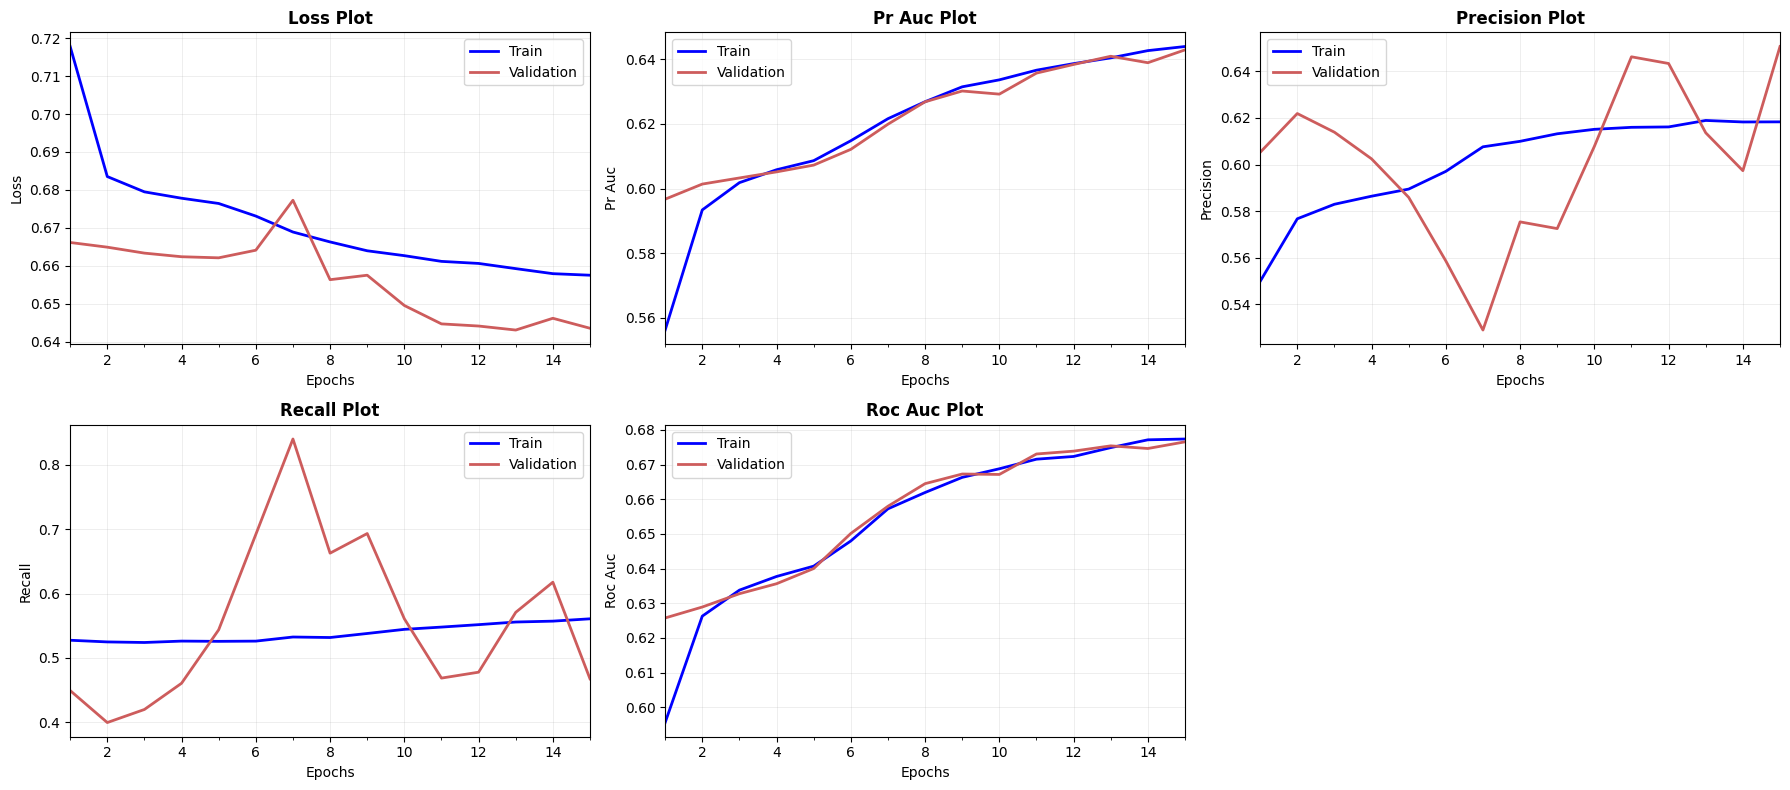

In [49]:
plot_model_report(history= history_fine_tuned.history)

Evaluation using the default threshold of 0.5:

1863/1863 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
621/621 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 validation threshold: 0.500
Train Set Report:
              precision    recall  f1-score   support

           0       0.62      0.77      0.69     31515
           1       0.65      0.48      0.55     28090

    accuracy                           0.63     59605
   macro avg       0.64      0.62      0.62     59605
weighted avg       0.64      0.63      0.62     59605

Validation Set Report:
              precision    recall  f1-score   support

           0       0.62      0.78      0.69     10506
           1       0.65      0.47      0.54      9363

    accuracy                           0.63     19869
   macro avg       0.64      0.62      0.62     19869
weighted avg       0.63      0.63      0.62     19869



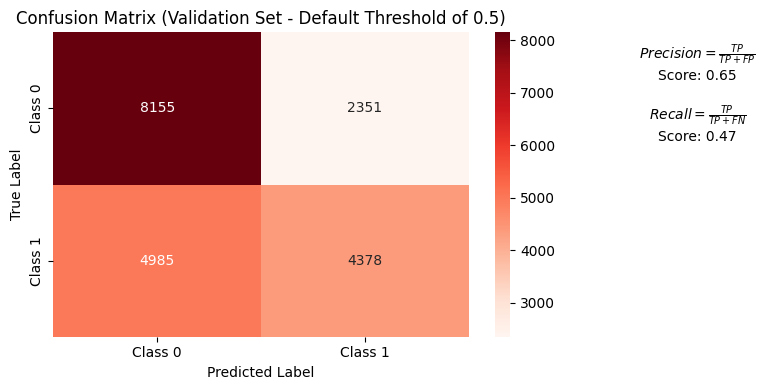

In [50]:
# after training the model
ypred_train_proba = model_finetuned.predict(train_inputs).ravel()
ypred_val_proba = model_finetuned.predict(val_inputs).ravel()

default_threshold = 0.5

print(f' validation threshold: {default_threshold:.3f}')

# converting to binary predictions
ypred_train_binary = (ypred_train_proba >= default_threshold).astype(int).flatten()
ypred_val_binary = (ypred_val_proba >= default_threshold).astype(int).flatten()

# Now evaluate using evaluation function
print('Train Set Report:')
recall_tr, precision_tr, f1_tr, acc_tr, cl_report_tr = \
    evaluate_predictions(true_values= y_train,
                         predictions= ypred_train_binary,
                         print_class_report= True)
print('Validation Set Report:')
recall_vl, precision_vl, f1_vl, acc_vl, cl_report_vl = \
    evaluate_predictions(true_values= y_val,
                         predictions= ypred_val_binary,
                         print_class_report=True)

# Plot confusion matrix (validation set)
scores = plot_confusion_matrix(y_true=y_val['readmitted'],
                               y_pred= ypred_val_binary,
                               fig_size= (8, 4),
                               title='Confusion Matrix (Validation Set - Default Threshold of 0.5)',
                               colour_map='Reds')

### Part 4: Choosing a validation-set threshold and converting predictions to binary


In [51]:
def find_best_threshold(y_true, y_proba, metric= 'f1', min_precision= None):
    """
    Finds the optimal probability threshold for binary classification based on a given metric,
    while optionally enforcing a minimum precision constraint.

    Given the true binary labels and the predicted probabilities, this function evaluates various
    threshold values and calculates their corresponding performance metrics (precision, recall, F1-score,
    accuracy). It allows the user to specify whether the optimization should prioritize a particular metric,
    such as 'f1', 'recall', or 'precision'. Optionally, a minimum precision threshold can be enforced,
    which will exclude thresholds that do not satisfy the precision requirement.

    :param y_true: Array-like of shape (n_samples,) containing the ground-truth binary labels. Input data is
        expected to be in binary {0, 1} format.
    :param y_proba: Array-like of shape (n_samples,) containing the predicted probabilities for the positive
        class (class 1). Probabilities should be in the range [0.0, 1.0].
    :param metric: Optional string value specifying the performance metric to optimize. Default is 'f1'.
        Allowed values include 'f1', 'precision', 'recall', and 'pr_auc'.
        PR-AUC is calculated from the predicted probabilities and is therefore threshold-independent;
        when metric='pr_auc', F1-score is used as the tie-breaker for selecting a threshold.
    :param min_precision: Optional float value specifying the minimum precision constraint. If provided,
        thresholds that result in a precision below this value will be penalized by assigning a negative
        infinity score.

    :return: A tuple containing two elements:
        - Best threshold value (float) optimizing the specified metric.
        - A pandas DataFrame containing detailed performance metrics (threshold, precision, recall,
          F1-score, accuracy, and score) for all evaluated thresholds across the range [0.05, 0.95].
    """
    y_true = np.asarray(y_true).ravel()
    y_proba = np.asarray(y_proba).ravel()
    valid_metrics = {'f1', 'precision', 'recall', 'pr_auc'}
    if metric not in valid_metrics:
        raise ValueError(f"metric must be one of {sorted(valid_metrics)}")

    # average_precision_score summarizes a precision-recall curve
    # as the weighted mean of precisions achieved at each threshold,
    # with the increase in recall from the previous threshold used as the weight
    pr_auc = average_precision_score(y_true, y_proba)
    thresholds = np.linspace(0.05, 0.95, 181)

    rows = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        precision = precision_score(y_true, y_pred, zero_division= 0)
        recall = recall_score(y_true, y_pred, zero_division= 0)
        f1 = f1_score(y_true, y_pred, zero_division= 0)
        accuracy = accuracy_score(y_true, y_pred)

        if metric == 'recall':
            score = recall
        elif metric == 'precision':
            score = precision
        elif metric == 'pr_auc':
            score = pr_auc
        else:
            score = f1

        if min_precision is not None and precision < min_precision:
            score = -np.inf

        rows.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'accuracy': accuracy,
            'pr_auc': pr_auc,
            'score': score,
        })

    threshold_results = pd.DataFrame(rows)
    sort_columns = ['score', 'f1_score'] if metric == 'pr_auc' else ['score']
    best_row = threshold_results.sort_values(sort_columns, ascending=False).iloc[0]

    return float(best_row['threshold']), threshold_results

1863/1863 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
621/621 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Best validation threshold: 0.275


,threshold,precision,recall,f1_score,accuracy,pr_auc,score
45,0.275,0.514939,0.916693,0.659445,0.553828,0.643031,0.659445
44,0.270,0.513142,0.921606,0.659231,0.551009,0.643031,0.659231
46,0.280,0.516708,0.909965,0.659137,0.556495,0.643031,0.659137
47,0.285,0.518596,0.903984,0.659087,0.559314,0.643031,0.659087
43,0.265,0.511004,0.927481,0.658952,0.547587,0.643031,0.658952


              precision    recall  f1-score   support

           0       0.76      0.22      0.35     31515
           1       0.51      0.92      0.66     28090

    accuracy                           0.55     59605
   macro avg       0.64      0.57      0.50     59605
weighted avg       0.65      0.55      0.50     59605

              precision    recall  f1-score   support

           0       0.76      0.23      0.35     10506
           1       0.51      0.92      0.66      9363

    accuracy                           0.55     19869
   macro avg       0.64      0.57      0.51     19869
weighted avg       0.64      0.55      0.50     19869



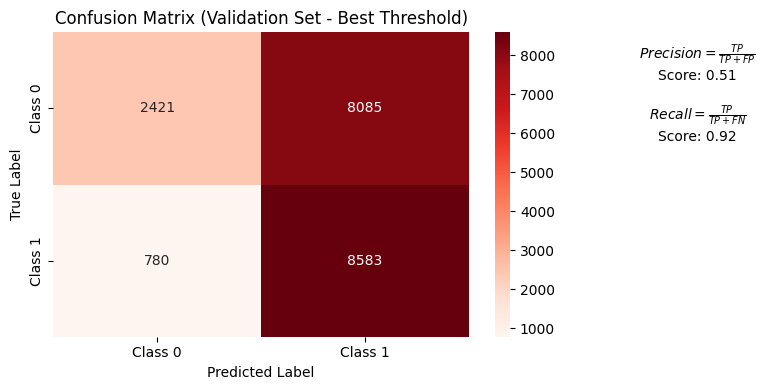

In [52]:
# after training the model
ypred_train_proba = model_finetuned.predict(train_inputs).ravel()
ypred_val_proba = model_finetuned.predict(val_inputs).ravel()

# Select threshold on validation set only.
best_threshold, threshold_results = find_best_threshold(
    y_true= y_val_array,
    y_proba= ypred_val_proba,
    metric='f1'
)

print(f'Best validation threshold: {best_threshold:.3f}')
display(threshold_results.sort_values('score', ascending=False).head())

# converting to binary predictions
ypred_train_binary = (ypred_train_proba >= best_threshold).astype(int).flatten()
ypred_val_binary = (ypred_val_proba >= best_threshold).astype(int).flatten()

# Now evaluate using your evaluation function
recall_tr, precision_tr, f1_tr, acc_tr, cl_report_tr = \
    evaluate_predictions(true_values= y_train,
                         predictions= ypred_train_binary,
                         print_class_report=True)

recall_vl, precision_vl, f1_vl, acc_vl, cl_report_vl = \
    evaluate_predictions(true_values= y_val,
                         predictions= ypred_val_binary,
                         print_class_report= True)

# Plot confusion matrix (validation set)
scores = plot_confusion_matrix(y_true= y_val['readmitted'],
                               y_pred= ypred_val_binary,
                               fig_size= (8, 4),
                               title='Confusion Matrix (Validation Set - Best Threshold)',
                               colour_map='Reds')


### Part 5: Test Set Evaluation

Generating predictions on test data...
621/621 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test set size: 19869 samples
Predictions generated: 19869
Classification threshold before calibration: 0.500
Classification threshold after calibration: 0.275
-------
Classification Report using the default (0.5) threshold:
              precision    recall  f1-score   support

           0       0.62      0.77      0.69     10506
           1       0.65      0.46      0.54      9363

    accuracy                           0.63     19869
   macro avg       0.63      0.62      0.61     19869
weighted avg       0.63      0.63      0.62     19869



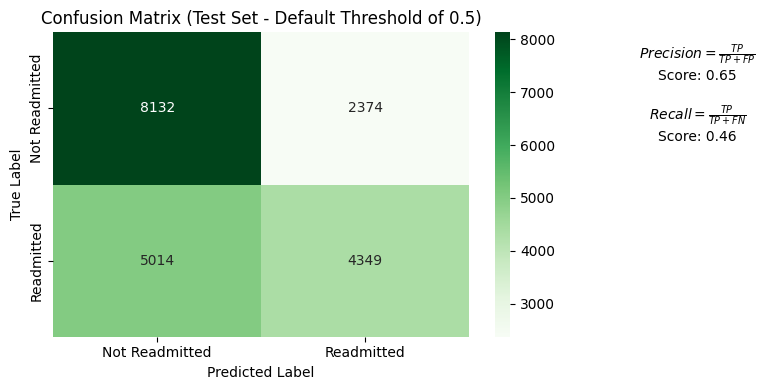

Classification Report using the best threshold:
              precision    recall  f1-score   support

           0       0.75      0.23      0.35     10506
           1       0.51      0.92      0.66      9363

    accuracy                           0.55     19869
   macro avg       0.63      0.57      0.51     19869
weighted avg       0.64      0.55      0.50     19869



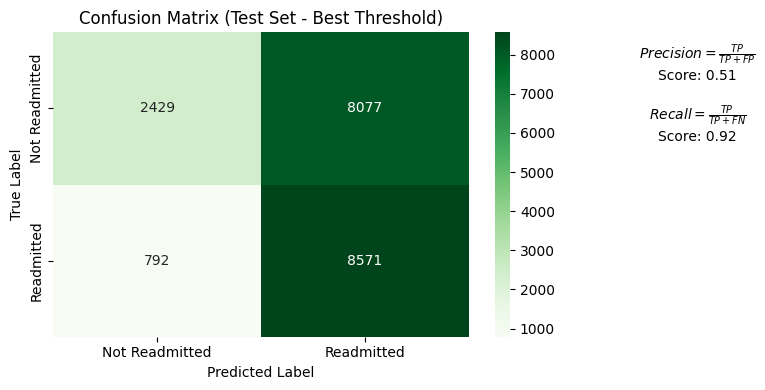

In [53]:
# Generate predictions on test set
print('Generating predictions on test data...')
ypred_test_proba = model_finetuned.predict(test_inputs).ravel()

# use the default threshold: 0.5
ypred_test_binary_default = (ypred_test_proba >= default_threshold).astype(int).flatten()

# Convert to binary predictions using the validation-selected threshold.
ypred_test_binary = (ypred_test_proba >= best_threshold).astype(int).flatten()

print(f'Test set size: {len(y_test)} samples')
print(f'Predictions generated: {len(ypred_test_binary)}')
print(f'Classification threshold before calibration: {default_threshold:.3f}')
print(f'Classification threshold after calibration: {best_threshold:.3f}')
print('-------')


print('Classification Report using the default (0.5) threshold:')
# Classification Report:
recall_test, precision_test, f1_test, acc_test, cl_report_test = (
    evaluate_predictions(true_values=y_test,
                         predictions= ypred_test_binary_default,
                         print_class_report=True)
)

# confusion matrix
scores_test = plot_confusion_matrix(y_true=y_test['readmitted'],
                                    y_pred= ypred_test_binary_default,
                                    fig_size=(8, 4),
                                    class_names=['Not Readmitted', 'Readmitted'],
                                    title='Confusion Matrix (Test Set - Default Threshold of 0.5)',
                                    colour_map='Greens')

#############
print('Classification Report using the best threshold:')
# Classification Report:
recall_test, precision_test, f1_test, acc_test, cl_report_test = (
    evaluate_predictions(true_values=y_test,
                         predictions=ypred_test_binary,
                         print_class_report=True)
)

# confusion matrix
scores_test = plot_confusion_matrix(y_true=y_test['readmitted'],
                                    y_pred=ypred_test_binary,
                                    fig_size=(8, 4),
                                    class_names=['Not Readmitted', 'Readmitted'],
                                    title='Confusion Matrix (Test Set - Best Threshold)',
                                    colour_map='Greens')

In [54]:
# Summarising evaluation metrics
print()
print('-' * 30)
print('TEST SET PERFORMANCE SUMMARY')
print('-' * 30)
print(f'Threshold: {best_threshold:.3f}')
print(f'Accuracy:  {acc_test:.4f}')
print(f'Recall:    {recall_test:.4f}')
print(f'Precision: {precision_test:.4f}')
print(f'F1-Score:  {f1_test:.4f}')
print('-' * 30)
print()

# storing results for comparison
test_results = {
    'dataset': 'test',
    'n_samples': len(y_test),
    'threshold': best_threshold,
    'accuracy': acc_test,
    'recall': recall_test,
    'precision': precision_test,
    'f1_score': f1_test,
    'confusion_matrix': scores_test['confusion_matrix']
}



------------------------------
TEST SET PERFORMANCE SUMMARY
------------------------------
Threshold: 0.275
Accuracy:  0.5536
Recall:    0.9154
Precision: 0.5148
F1-Score:  0.6590
------------------------------



In [55]:
test_results

{'dataset': 'test',
 'n_samples': 19869,
 'threshold': 0.27499999999999997,
 'accuracy': 0.5536262519502743,
 'recall': 0.9154117270105735,
 'precision': 0.5148366170110524,
 'f1_score': 0.6590288724001384,
 'confusion_matrix': array([[2429, 8077],
        [ 792, 8571]])}

**Saving the model:**

In [56]:
MODEL_NAME = 'tabtransformer_allfeats'
MODEL_PATH = export_dir / f"{MODEL_NAME}_finetuned.keras"
model_finetuned.save(MODEL_PATH)

# Save the Optuna trial history for later comparison.
optuna_trials_path = export_dir / f"{MODEL_NAME}_optuna_trials.csv"
study.trials_dataframe().to_csv(optuna_trials_path, index=False)

# Save the best hyperparameters as a readable JSON file.
best_params_path = export_dir / f"{MODEL_NAME}_best_params.json"
with open(best_params_path, 'w') as f:
    json.dump(best_params, f, indent=2)

# Save all validation thresholds so the chosen threshold can be audited later.
threshold_results_path = export_dir / f"{MODEL_NAME}_threshold_results.csv"
threshold_results.to_csv(threshold_results_path, index=False)

# Convert NumPy values to plain Python values before writing JSON.
test_results_to_save = {
    key: (value.tolist() if hasattr(value, 'tolist') else value)
    for key, value in test_results.items()
}

test_results_path = export_dir / f"{MODEL_NAME}_test_results.json"
with open(test_results_path, 'w') as f:
    json.dump(test_results_to_save, f, indent= 2)

print(f"Model saved to: {MODEL_PATH.resolve()}")
print(f"Optuna trials saved to: {optuna_trials_path.resolve()}")
print(f"Best parameters saved to: {best_params_path.resolve()}")
print(f"Threshold results saved to: {threshold_results_path.resolve()}")
print(f"Test results saved to: {test_results_path.resolve()}")

Model saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/tabtransformer/tabtransformer_allfeats_finetuned.keras
Optuna trials saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/tabtransformer/tabtransformer_allfeats_optuna_trials.csv
Best parameters saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/tabtransformer/tabtransformer_allfeats_best_params.json
Threshold results saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/tabtransformer/tabtransformer_allfeats_threshold_results.csv
Test results saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/tabtransformer/tabtransformer_allfeats_test_results.json
